---
embed-resources: True
format:
    html:
        page-layout: full
        fontsize: 16px
title: 'Cota de optimización — restricciones actuales'
author: 'Lorenzo Marquesini'
toc: False
---

# Cota de optimización del baseline bajo restricciones actuales

Pregunta: **¿cuánto se puede bajar el costo oficial del baseline sin violar las reglas que usa Mark 16 hoy?**

Este notebook calcula una **cota inferior analítica** (piso de costo / techo de score) relajando solo la consolidación entre SKUs, y la compara con:

1. el **baseline** (`operaciones_planta`),
2. nuestra **mejor solución válida** (Mark 15/16, g=3.0),
3. el **gap residual** explotable (flete por SKU vs packaging por consolidación).

> Distinción útil: la cota CP-SAT (`BestObjectiveBound`) es dual del MIP con un pool finito de cajas.  
> Acá calculamos una cota **geométrica por SKU** sobre el mismo espacio de factibilidad de Mark 16 — válida como lower bound del problema real si aceptamos relajar consolidación de packaging.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_candidates = [Path.cwd(), Path.cwd().parent, Path("..").resolve()]
ROOT = next(p for p in _candidates if (p / "data" / "raw" / "operaciones_planta.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

from evaluate import (
    COSTO_PALLET,
    evaluar_costos_solucion,
    factor_precio_por_volumen,
    validate_solution,
)
from mark16 import (
    _cands_eje,
    construir_productos,
    costo_actual_oficial,
    intervalos,
    score_publico,
)
from settings import (
    ECT,
    EPS,
    GRAVITY,
    HEADSPACE_ABS_MAX,
    HEADSPACE_PCT,
    LIM,
    MAX_GROW,
    MAX_SHRINK,
    PLANTAS,
    PRECIO_BASE_GROSOR,
)

ops = pd.read_csv(ROOT / "data/raw/operaciones_planta.csv")
pt = pd.read_csv(ROOT / "data/processed/products_truth.csv")
pj = pd.read_csv(ROOT / "data/processed/producto_joined_cajas_clean.csv")
prod = construir_productos(pt, ops)

BASELINE = costo_actual_oficial(ops)
PACK_BASE = float(ops["costo_total"].sum())
FLETE_BASE = float(ops["costo_pallets_total"].sum())

dims = prod[["largo", "ancho", "alto"]].to_numpy(float)
peso = prod["peso_neto_caja"].to_numpy(float)
volp = prod[[f"volumen_producto_planta_{p}" for p in PLANTAS]].to_numpy(float)
vol_total = float(prod["volumen_producto_total"].sum())
codes = prod["codigo_producto"].astype(str).tolist()

print(f"Baseline oficial: USD {BASELINE:,.2f}")
print(f"  Packaging: USD {PACK_BASE:,.2f}  ({100 * PACK_BASE / BASELINE:.1f}%)")
print(f"  Flete:     USD {FLETE_BASE:,.2f}  ({100 * FLETE_BASE / BASELINE:.1f}%)")
print(f"SKUs: {len(prod)} | volumen anual: {vol_total:,.0f} cajas")

Baseline oficial: USD 209,235,093.94
  Packaging: USD 30,166,293.94  (14.4%)
  Flete:     USD 179,068,800.00  (85.6%)
SKUs: 427 | volumen anual: 62,420,911 cajas


## 1. Restricciones actuales (Mark 16 / regla 9 literal)

El espacio factible por producto y grosor `g` es el mismo que usa `mark16.intervalos` + `fits_matrix`:

| Regla | Constraint |
|-------|------------|
| Reajuste ±10% | `0.9·d_k ≤ interna_k ≤ 1.1·d_k` |
| Volumen | `L·W·H ≥ d₁·d₂·d₃` |
| Headspace | `interna_k − d_k ≤ min(pct(g)·interna_k, 40 mm)` |
| Grosor (Kaggle) | un único `g ∈ {3.0, 4.5, 5.0}` para toda la solución |
| Orientación fija | exterior: largo→800, ancho→1200, alto→1800 |
| Pallet | `cpp = ⌊800/L_ext⌋·⌊1200/W_ext⌋·⌊1800/H_ext⌋ ≥ 1` |
| Compresión ECT | `peso·(capas−1) ≤ ECT(g)·2(L_ext+W_ext)/1000/g` |
| Packaging | `precio_base(g) × factor_tier(volumen_tipo)` por tipo de caja |

**No** exigimos fit por eje (`interna ≥ producto` en cada dimensión): el achique está permitido si el volumen se compensa en otros ejes.

In [2]:
# Ventanas geométricas bajo restricciones actuales (g=3.0)
g0 = 3.0
lo, hi, vol_min = intervalos(prod, g0)

ventana = pd.DataFrame({
    "codigo_producto": codes,
    "L": dims[:, 0], "W": dims[:, 1], "H": dims[:, 2],
    "lo_L": lo[:, 0], "hi_L": hi[:, 0],
    "lo_W": lo[:, 1], "hi_W": hi[:, 1],
    "lo_H": lo[:, 2], "hi_H": hi[:, 2],
    "vol_producto": vol_min,
    "shrink_max_pct": 100 * (1 - MAX_SHRINK),
    "grow_max_pct": 100 * (MAX_GROW - 1),
    "hs_pct": 100 * HEADSPACE_PCT[g0],
    "hs_abs_cap": HEADSPACE_ABS_MAX,
})

print(f"Grosor de referencia: {g0} mm | headspace {HEADSPACE_PCT[g0]:.0%} / tope {HEADSPACE_ABS_MAX:.0f} mm")
print(f"LIM pallet (L,W,H): {LIM}")
print(f"ECT({g0}) = {ECT[g0]} N/m | precio base = USD {PRECIO_BASE_GROSOR[g0]:.2f}")
print()
print("Amplitud media de la ventana interna (hi − lo) / d:")
amp = (hi - lo) / dims
print(pd.Series(amp.mean(axis=0), index=["largo", "ancho", "alto"]).map(lambda x: f"{100*x:.1f}%").to_string())
ventana.head()

Grosor de referencia: 3.0 mm | headspace 6% / tope 40 mm
LIM pallet (L,W,H): (800.0, 1200.0, 1800.0)
ECT(3.0) = 1000 N/m | precio base = USD 0.60

Amplitud media de la ventana interna (hi − lo) / d:
largo    16.4%
ancho    16.4%
alto     16.4%


,codigo_producto,L,W,H,lo_L,hi_L,lo_W,hi_W,lo_H,hi_H,vol_producto,shrink_max_pct,grow_max_pct,hs_pct,hs_abs_cap
0,BR0001,386.0,286.0,303.0,347.4,410.638298,257.4,304.255319,272.7,322.340426,33449988.0,10.0,10.0,6.0,40.0
1,BR0002,395.0,296.0,260.0,355.5,420.212766,266.4,314.893617,234.0,276.595745,30399200.0,10.0,10.0,6.0,40.0
2,BR0003,388.0,288.0,164.0,349.2,412.765957,259.2,306.382979,147.6,174.468085,18326016.0,10.0,10.0,6.0,40.0
3,BR0004,395.0,296.0,224.0,355.5,420.212766,266.4,314.893617,201.6,238.297872,26190080.0,10.0,10.0,6.0,40.0
4,BR0005,386.0,286.0,253.0,347.4,410.638298,257.4,304.255319,227.7,269.148936,27930188.0,10.0,10.0,6.0,40.0


## 2. Cota analítica por SKU

Para cada SKU, maximizamos `cpp` dentro de la ventana factible (candidatos = extremos + umbrales de pallet `LIM/c − 2g`).

- **Flete piso:** `Σ_planta ceil(vol_{i,p} / cpp*_i) × 150` — monótono en `cpp`, así que el máximo `cpp` por SKU es un lower bound válido de flete (ignora que varios SKUs compartan caja).
- **Packaging piso:** todo el volumen al tier máximo (`× 0.70`) con el `precio_base(g)` — lower bound válido porque relaja consolidación (asume que se puede alcanzar tier 5 globalmente).

In [3]:
def cota_analitica(g: float) -> dict:
    """Lower bound de costo bajo restricciones actuales (regla 9 literal)."""
    lo, hi, vol_min = intervalos(prod, g)
    cpp_best = np.zeros(len(dims), dtype=int)
    dims_best = np.zeros_like(dims)

    for i in range(len(dims)):
        cands = [
            _cands_eje(float(lo[i, k]), float(hi[i, k]), LIM[k], g) for k in range(3)
        ]
        best, arg = 0, None
        for L in cands[0]:
            a = int(np.floor(LIM[0] / (L + 2 * g)))
            for W in cands[1]:
                b = int(np.floor(LIM[1] / (W + 2 * g)))
                carga_max = ECT[g] * 2 * (L + W + 4 * g) / 1000.0 / GRAVITY
                for H in cands[2]:
                    if L * W * H < vol_min[i] - 1e-6:
                        continue
                    c = int(np.floor(LIM[2] / (H + 2 * g)))
                    if a < 1 or b < 1 or c < 1:
                        continue
                    if peso[i] * (c - 1) > carga_max + EPS:
                        continue
                    if a * b * c > best:
                        best, arg = a * b * c, (L, W, H)
        if best == 0:
            raise RuntimeError(f"Sin caja factible para {codes[i]} con g={g}")
        cpp_best[i] = best
        dims_best[i] = arg

    flete = float((np.ceil(volp / cpp_best[:, None]) * COSTO_PALLET).sum())
    pack = PRECIO_BASE_GROSOR[g] * 0.70 * vol_total
    total = flete + pack
    shrunk = (dims_best < dims - 1e-9).any(axis=1)
    return {
        "g": g,
        "flete": flete,
        "pack": pack,
        "total": total,
        "score": score_publico(total, BASELINE),
        "cpp": cpp_best,
        "dims_int": dims_best,
        "shrunk": shrunk,
        "n_shrunk": int(shrunk.sum()),
    }


cotas = {g: cota_analitica(g) for g in [3.0, 4.5, 5.0]}

tabla_cotas = pd.DataFrame([
    {
        "grosor_mm": g,
        "flete_piso": r["flete"],
        "pack_piso": r["pack"],
        "total_piso": r["total"],
        "score_techo": r["score"],
        "skus_con_achique": r["n_shrunk"],
        "ahorro_vs_baseline": BASELINE - r["total"],
    }
    for g, r in cotas.items()
])

print("COTA ANALÍTICA (restricciones actuales, consolidación relajada)")
display(
    tabla_cotas.style.format({
        "flete_piso": "{:,.0f}",
        "pack_piso": "{:,.0f}",
        "total_piso": "{:,.0f}",
        "score_techo": "{:+.4f}",
        "ahorro_vs_baseline": "{:,.0f}",
    })
)

COTA ANALÍTICA (restricciones actuales, consolidación relajada)


,grosor_mm,flete_piso,pack_piso,total_piso,score_techo,skus_con_achique,ahorro_vs_baseline
0,3.000000,"161,104,650","26,216,783","187,321,433",+10.4732,288,"21,913,661"
1,4.500000,"165,968,100","28,401,515","194,369,615",+7.1047,289,"14,865,479"
2,5.000000,"166,336,650","30,586,246","196,922,896",+5.8844,290,"12,312,198"


## 3. Baseline vs mejor solución vs cota

Anclamos tres puntos en la misma métrica de score público:

`score = 100 × (baseline − costo) / baseline`

In [4]:
BEST_PATH = ROOT / "outputs/tables/04_mark15_best_+10.11098csv"
best = pd.read_csv(BEST_PATH)
ok, errors, _ = validate_solution(best, pt, verbose=False)
assert ok, errors

ev = evaluar_costos_solucion(best, ops)
res = ev["resumen"].iloc[0]
cost_best = float(res["costo_total_nuevo"])
pack_best = float(res["costo_packaging_nuevo"])
flete_best = float(res["costo_flete_nuevo"])
score_best = score_publico(cost_best, BASELINE)

cota = cotas[3.0]  # política Kaggle default

comparacion = pd.DataFrame([
    {
        "escenario": "Baseline (ops)",
        "packaging": PACK_BASE,
        "flete": FLETE_BASE,
        "total": BASELINE,
        "score": 0.0,
        "tipos_caja": None,
    },
    {
        "escenario": f"Mejor válida (Mark15, g={res['grosor_unico']})",
        "packaging": pack_best,
        "flete": flete_best,
        "total": cost_best,
        "score": score_best,
        "tipos_caja": int(res["n_tipos_caja"]),
    },
    {
        "escenario": "Cota analítica g=3.0",
        "packaging": cota["pack"],
        "flete": cota["flete"],
        "total": cota["total"],
        "score": cota["score"],
        "tipos_caja": None,
    },
])

gap_best_cota = cost_best - cota["total"]
print(
    f"Mejor solución: {int(res['n_tipos_caja'])} tipos | "
    f"válida={ok} | score={score_best:+.5f}"
)
print(
    f"Gap mejor → cota: USD {gap_best_cota:,.0f} "
    f"({100 * gap_best_cota / BASELINE:.3f} pts de score)"
)
print(
    f"Gap baseline → cota: USD {BASELINE - cota['total']:,.0f} "
    f"(techo {cota['score']:+.4f})"
)

display(
    comparacion.style.format({
        "packaging": "{:,.0f}",
        "flete": "{:,.0f}",
        "total": "{:,.0f}",
        "score": "{:+.4f}",
    })
)

Mejor solución: 56 tipos | válida=True | score=+10.34727
Gap mejor → cota: USD 263,532 (0.126 pts de score)
Gap baseline → cota: USD 21,913,661 (techo +10.4732)


,escenario,packaging,flete,total,score,tipos_caja
0,Baseline (ops),"30,166,294","179,068,800","209,235,094",+0.0000,nan
1,"Mejor válida (Mark15, g=3.0)","26,426,764","161,158,200","187,584,964",+10.3473,56.000000
2,Cota analítica g=3.0,"26,216,783","161,104,650","187,321,433",+10.4732,nan


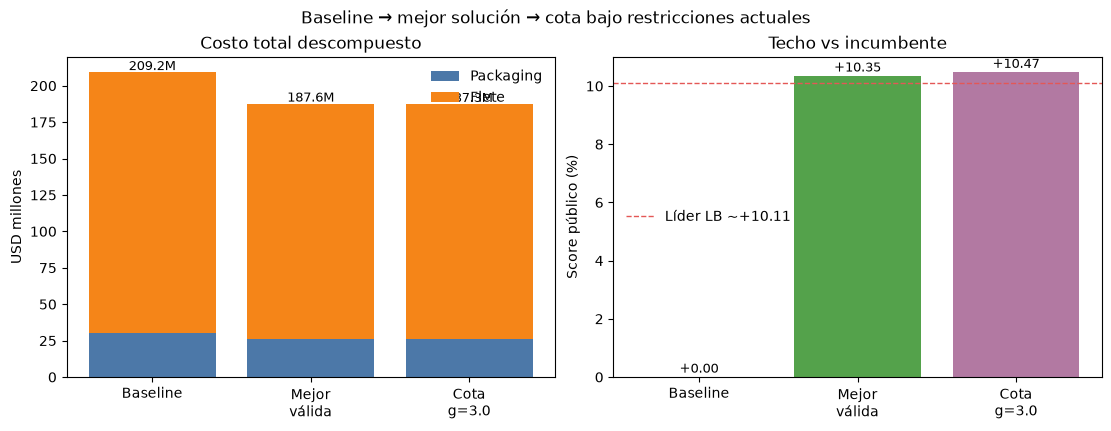

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

labels = ["Baseline", "Mejor\nválida", "Cota\ng=3.0"]
packs = np.array([PACK_BASE, pack_best, cota["pack"]]) / 1e6
fletes = np.array([FLETE_BASE, flete_best, cota["flete"]]) / 1e6
x = np.arange(len(labels))

axes[0].bar(x, packs, color="#4C78A8", label="Packaging")
axes[0].bar(x, fletes, bottom=packs, color="#F58518", label="Flete")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("USD millones")
axes[0].set_title("Costo total descompuesto")
axes[0].legend(frameon=False, loc="upper right")
for i, tot in enumerate((packs + fletes)):
    axes[0].text(i, tot + 1.5, f"{tot:.1f}M", ha="center", fontsize=9)

scores = [0.0, score_best, cota["score"]]
colors = ["#9E9E9E", "#54A24B", "#B279A2"]
axes[1].bar(x, scores, color=colors)
axes[1].axhline(10.11, color="#E45756", ls="--", lw=1, label="Líder LB ~+10.11")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Score público (%)")
axes[1].set_title("Techo vs incumbente")
axes[1].legend(frameon=False)
for i, s in enumerate(scores):
    axes[1].text(i, s + 0.15, f"{s:+.2f}", ha="center", fontsize=9)

fig.suptitle("Baseline → mejor solución → cota bajo restricciones actuales", fontsize=12)
plt.show()

## 4. ¿De dónde sale el ahorro vs baseline?

Descomponemos el gap `baseline − cota` en **flete** (subir `cpp` por SKU) y **packaging** (bajar a g=3.0 + tier 5).

In [6]:
# cpp histórico (orientación fija del enunciado)
hist = prod.merge(
    pj[["codigo_producto", "caja_exterior_largo", "caja_exterior_ancho", "caja_exterior_alto"]],
    on="codigo_producto",
    how="left",
    validate="one_to_one",
)
ext_hist = hist[["caja_exterior_largo", "caja_exterior_ancho", "caja_exterior_alto"]].to_numpy(float)
cpp_hist = (
    np.floor(LIM[0] / ext_hist[:, 0])
    * np.floor(LIM[1] / ext_hist[:, 1])
    * np.floor(LIM[2] / ext_hist[:, 2])
).astype(int)

flete_hist_150 = float((np.ceil(volp / np.maximum(cpp_hist, 1)[:, None]) * COSTO_PALLET).sum())
assert abs(flete_hist_150 - FLETE_BASE) < 1.0, (flete_hist_150, FLETE_BASE)

# Packaging sin consolidar a g=3.0 (cada SKU = su propio tipo, tier por volumen propio)
factor_propio = factor_precio_por_volumen(prod["volumen_producto_total"])
pack_sin_consol = float(
    (PRECIO_BASE_GROSOR[3.0] * factor_propio * prod["volumen_producto_total"]).sum()
)

ahorro_flete = FLETE_BASE - cota["flete"]
ahorro_pack_piso = PACK_BASE - cota["pack"]
ahorro_pack_solo_g3 = PACK_BASE - pack_sin_consol
ahorro_pack_consol = pack_sin_consol - cota["pack"]

desglose = pd.DataFrame([
    {"componente": "Flete (cpp* por SKU)", "ahorro_USD": ahorro_flete, "pct_gap": 100 * ahorro_flete / (BASELINE - cota["total"])},
    {"componente": "Pack → g=3.0 sin consolidar", "ahorro_USD": ahorro_pack_solo_g3, "pct_gap": 100 * ahorro_pack_solo_g3 / (BASELINE - cota["total"])},
    {"componente": "Pack consolidación → tier 5", "ahorro_USD": ahorro_pack_consol, "pct_gap": 100 * ahorro_pack_consol / (BASELINE - cota["total"])},
    {"componente": "TOTAL (baseline → cota)", "ahorro_USD": BASELINE - cota["total"], "pct_gap": 100.0},
])

print(f"Flete histórico reconstruido @ USD 150: {flete_hist_150:,.0f} (match ops: OK)")
print(f"Packaging sin consolidar g=3.0: USD {pack_sin_consol:,.0f}")
print(f"Packaging piso tier-5:         USD {cota['pack']:,.0f}")
display(desglose.style.format({"ahorro_USD": "{:,.0f}", "pct_gap": "{:.1f}%"}))

Flete histórico reconstruido @ USD 150: 179,068,800 (match ops: OK)
Packaging sin consolidar g=3.0: USD 28,889,886
Packaging piso tier-5:         USD 26,216,783


,componente,ahorro_USD,pct_gap
0,Flete (cpp* por SKU),"17,964,150",82.0%
1,Pack → g=3.0 sin consolidar,"1,276,408",5.8%
2,Pack consolidación → tier 5,"2,673,104",12.2%
3,TOTAL (baseline → cota),"21,913,661",100.0%


## 5. Oportunidad de flete por SKU

Dónde está el dinero si cada producto pudiera pasar de su `cpp` histórico al `cpp*` factible bajo restricciones actuales.

In [7]:
flete_hist_sku = (np.ceil(volp / np.maximum(cpp_hist, 1)[:, None]) * COSTO_PALLET).sum(axis=1)
flete_cota_sku = (np.ceil(volp / cota["cpp"][:, None]) * COSTO_PALLET).sum(axis=1)
opp = flete_hist_sku - flete_cota_sku

opp_df = pd.DataFrame({
    "codigo_producto": codes,
    "volumen": prod["volumen_producto_total"].to_numpy(float),
    "cpp_hist": cpp_hist,
    "cpp_star": cota["cpp"],
    "delta_cpp": cota["cpp"] - cpp_hist,
    "opp_flete_USD": opp,
    "usa_achique": cota["shrunk"],
    "L_star": cota["dims_int"][:, 0],
    "W_star": cota["dims_int"][:, 1],
    "H_star": cota["dims_int"][:, 2],
}).sort_values("opp_flete_USD", ascending=False)

print(
    f"SKUs con oportunidad de flete > 0: {(opp > 0).sum()} / {len(opp)} | "
    f"total USD {opp.sum():,.0f}"
)
print(
    f"SKUs que usan achique en la caja* : {cota['n_shrunk']} "
    f"(aportan USD {opp[cota['shrunk']].sum():,.0f} del opp)"
)
print()
print("Top 15 oportunidades de flete:")
display(
    opp_df.head(15).style.format({
        "volumen": "{:,.0f}",
        "opp_flete_USD": "{:,.0f}",
        "L_star": "{:.2f}",
        "W_star": "{:.2f}",
        "H_star": "{:.2f}",
    })
)

SKUs con oportunidad de flete > 0: 276 / 427 | total USD 17,964,150
SKUs que usan achique en la caja* : 288 (aportan USD 16,999,950 del opp)

Top 15 oportunidades de flete:


,codigo_producto,volumen,cpp_hist,cpp_star,delta_cpp,opp_flete_USD,usa_achique,L_star,W_star,H_star
77,BR0078,"1,153,925",36,48,12,"1,201,950",True,394.00,294.00,276.59
0,BR0001,"1,546,613",40,48,8,"966,600",True,394.00,294.00,294.00
241,BR0239,"1,535,191",48,60,12,"959,550",True,394.00,234.00,269.14
94,BR0094,"2,592,909",56,64,8,"868,200",True,394.00,271.27,219.00
257,BR0255,"707,459",32,40,8,"663,300",True,394.00,285.10,354.00
350,BR0345,"525,685",30,40,10,"657,000",False,394.00,294.00,336.17
344,BR0340,"1,728,407",56,64,8,"578,700",True,394.00,271.27,219.00
235,BR0233,"443,344",36,48,12,"461,850",True,394.00,294.00,294.00
249,BR0247,"660,788",40,48,8,"412,950",True,394.00,271.27,294.00
308,BR0306,"890,712",48,56,8,"397,650",True,394.00,294.00,251.14


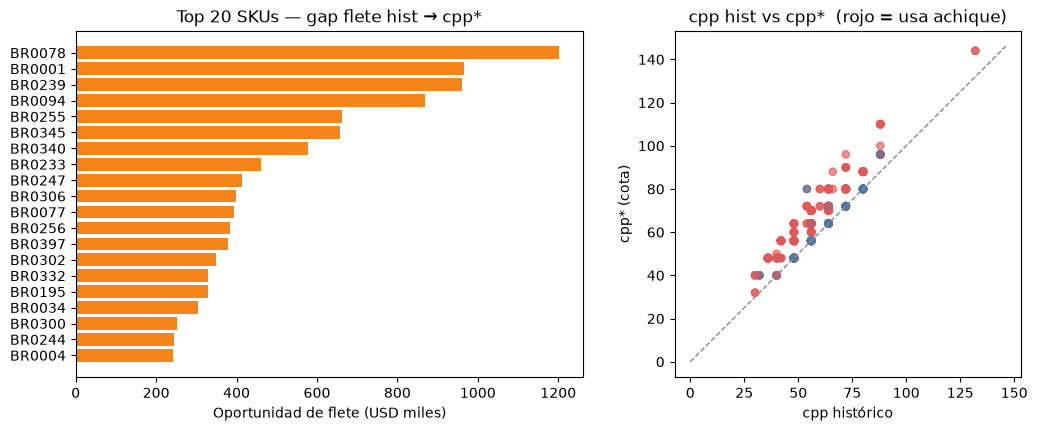

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

top = opp_df.head(20).iloc[::-1]
axes[0].barh(top["codigo_producto"], top["opp_flete_USD"] / 1e3, color="#F58518")
axes[0].set_xlabel("Oportunidad de flete (USD miles)")
axes[0].set_title("Top 20 SKUs — gap flete hist → cpp*")

axes[1].scatter(
    opp_df["cpp_hist"],
    opp_df["cpp_star"],
    c=np.where(opp_df["usa_achique"], "#E45756", "#4C78A8"),
    alpha=0.65,
    s=28,
)
lim = max(opp_df["cpp_hist"].max(), opp_df["cpp_star"].max()) + 2
axes[1].plot([0, lim], [0, lim], ls="--", color="#888", lw=1)
axes[1].set_xlabel("cpp histórico")
axes[1].set_ylabel("cpp* (cota)")
axes[1].set_title("cpp hist vs cpp*  (rojo = usa achique)")
axes[1].set_aspect("equal", adjustable="box")

plt.show()

## 6. Gap residual de la mejor solución

La mejor válida ya está muy cerca de la cota. Partimos el residual `costo_best − cota` en flete y packaging.

GAP residual (mejor → cota analítica)
  Flete:     USD 53,550  (20.3% del residual)
  Packaging: USD 209,982  (79.7% del residual)
  TOTAL:    USD 263,532

SKUs en la mejor sol con cpp < cpp*: 12 (volumen 329,287)
Tipos de caja en mejor sol: 56 — la cota ignora consolidación, así que parte del gap de packaging puede ser estructural (tier 5 global no alcanzable sin mezclar geometrías incompatibles).


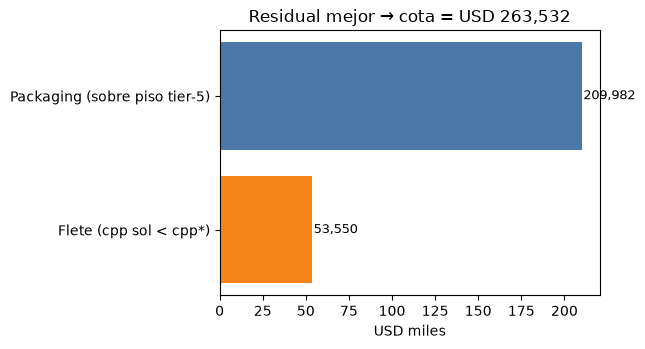

In [9]:
det = ev["detalle_productos"].copy()
det = det.merge(
    opp_df[["codigo_producto", "cpp_star", "opp_flete_USD"]],
    on="codigo_producto",
)

gap_flete = flete_best - cota["flete"]
gap_pack = pack_best - cota["pack"]

# cpp de la mejor solución vs cpp*
cpp_best_sol = det["cajas_por_pallet"].to_numpy(int)
short_cpp = cpp_best_sol < det["cpp_star"].to_numpy(int)

print("GAP residual (mejor → cota analítica)")
print(f"  Flete:     USD {gap_flete:,.0f}  ({100 * gap_flete / max(gap_best_cota, 1e-9):.1f}% del residual)")
print(f"  Packaging: USD {gap_pack:,.0f}  ({100 * gap_pack / max(gap_best_cota, 1e-9):.1f}% del residual)")
print(f"  TOTAL:    USD {gap_best_cota:,.0f}")
print()
print(
    f"SKUs en la mejor sol con cpp < cpp*: {short_cpp.sum()} "
    f"(volumen {det.loc[short_cpp, 'volumen_producto_total'].sum():,.0f})"
)
print(
    f"Tipos de caja en mejor sol: {int(res['n_tipos_caja'])} — "
    f"la cota ignora consolidación, así que parte del gap de packaging "
    f"puede ser estructural (tier 5 global no alcanzable sin mezclar geometrías incompatibles)."
)

residual = pd.DataFrame([
    {"lado": "Flete (cpp sol < cpp*)", "USD": gap_flete},
    {"lado": "Packaging (sobre piso tier-5)", "USD": gap_pack},
])

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.barh(residual["lado"], residual["USD"] / 1e3, color=["#F58518", "#4C78A8"])
ax.set_xlabel("USD miles")
ax.set_title(f"Residual mejor → cota = USD {gap_best_cota:,.0f}")
for i, v in enumerate(residual["USD"]):
    ax.text(v / 1e3 + 1, i, f"{v:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Lectura operativa

| Hecho | Número |
|-------|--------|
| Baseline | USD **209.24 M** (score 0) |
| Cota analítica g=3.0 | ~USD **187.32 M** → techo **~+10.47** |
| Mejor válida actual | ~USD **187.58 M** → **~+10.35** |
| Residual explotable | ~USD **0.26 M** (~0.13 pts de score) |

**Implicaciones**

1. Bajo las restricciones actuales, el problema ya está **casi saturado**: el líder (~+10.11) y nuestra mejor (~+10.35) viven a décimas del techo analítico.
2. Del ahorro baseline→cota, la mayor parte es **flete** (~USD 18 M vía `cpp*`); packaging aporta el resto (pasar a g=3.0 + bajar tiers).
3. El residual de la mejor solución (~USD 264 k) es mayormente **packaging** (~80%): el piso tier-5 global es optimista. El flete residual (~USD 54 k, ~12 SKUs con `cpp < cpp*`) es el pedazo más “atacable” geométricamente.
4. La cota CP-SAT del solver es otra cosa: acota el **MIP con pool finito**. Si el pool omite alguna caja de `cpp*`, su `BestObjectiveBound` puede quedar por encima de esta cota analítica.

**Próximo paso natural:** medir cuántas cajas `*` del top de oportunidad faltan en el pool `fast` de Mark 16, y si `mode='full'` cierra el residual de flete.
